#### Importación de librerías necesarias

In [29]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys
sys.path.insert(0, os.path.abspath("../"))
import src.visualizaciones as visualizaciones

from IPython.display import display

# omite advertencias
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#### Carga de Data

In [30]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset.csv")

#### Información inicial de Data

In [31]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [33]:
df.shape

(7043, 21)

* Este conjunto de datos consiste en 7043 registros y 21 características
* El dataset tiene muchas características como data de texto y probablemente sean variables categóricas
* **TotalCharges** contiene valores numéricos pero está almacenada como strings. Vamos a convertir esta variable a tipo numérica (float)
* La variable **SeniorCitizen** indica si el cliente es adulto mayor (0 = "no", 1 = "sí"). Al ser una variable categórica, la convertiremos de tipo numérico a object

# Manipulación de Datos

In [34]:
# convertir columnas de tipo string a object
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')
print(f"Total de columnas convertidas a object: {len(df.select_dtypes(include=['object']).columns)}")

Total de columnas convertidas a object: 18


In [35]:
# convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges convertido a numérico.")

TotalCharges convertido a numérico.


In [36]:
# convertir SeniorCitizen a object para que sea categórico
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: '0', 1: '1'}).astype(object)
print("SeniorCitizen convertido a object.")

SeniorCitizen convertido a object.


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* La variable objetivo que guiará nuestra exploración es el **Churn**.

# Análisis Exploratorio de Datos

### Análisis de completitud

In [38]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

* La columna **TotalCharges** tienen algunos valores faltantes

In [39]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


* En los registros donde **TotalCharges** presenta valores nulos, la antiguedad del cliente (**tenure**) es igual a 0. Por este motivo, y dado que la baja cantidad de valores faltantes no afectará la calidad del conjunto, es seguro reemplazar dichos valores faltantes por 0

In [40]:
# reemplazar valores nulos de TotalCharges por 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Valores nulos de TotalCharges reemplazados por 0.")

Valores nulos de TotalCharges reemplazados por 0.


### Análisis de valores duplicados

In [41]:
# registros duplicados
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")

Cantidad de registros duplicados: 0


* Tras la revisión, no se encontraron valores duplicados en el conjunto de datos

### Análisis de valores atípicos

In [42]:
# buscar valores atípicos usando el rango intercuartil
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    rango_intercuartil = q3 - q1

    limite_inferior = q1 - 1.5 * rango_intercuartil
    limite_superior = q3 + 1.5 * rango_intercuartil

    valores_atipicos = df[
        (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    ]

    if len(valores_atipicos) > 0:
        print(f"{columna}: sí presenta valores atípicos ({len(valores_atipicos)} registros).")
    else:
        print(f"{columna}: no presenta valores atípicos.")

tenure: no presenta valores atípicos.
MonthlyCharges: no presenta valores atípicos.
TotalCharges: no presenta valores atípicos.


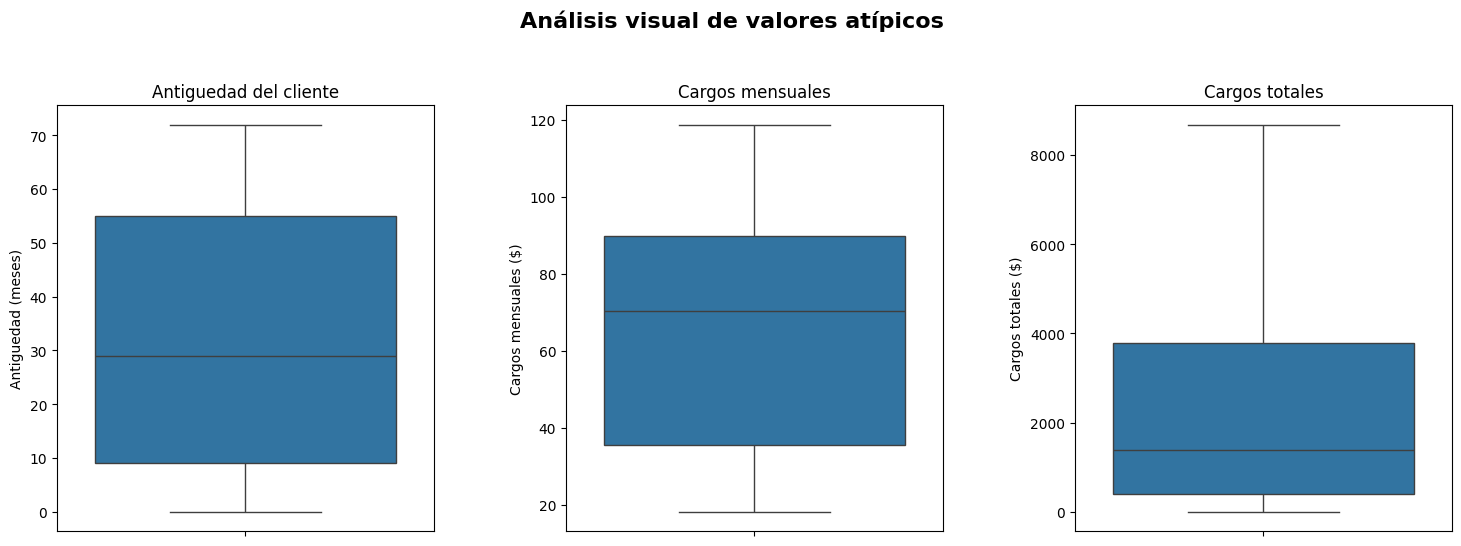

In [43]:
# crear una figura con múltiples espacios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Análisis visual de valores atípicos", fontsize=16, fontweight="bold")

# dibujar cada gráfico de caja con nombres descriptivos en español
sns.boxplot(y=df["tenure"], ax=axes[0])
axes[0].set_title("Antiguedad del cliente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Antiguedad (meses)")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Cargos mensuales")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cargos mensuales ($)")

sns.boxplot(y=df["TotalCharges"], ax=axes[2])
axes[2].set_title("Cargos totales")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cargos totales ($)")

plt.subplots_adjust(wspace=0.35, top=0.82)
plt.show()

* No se encontraron valores atípicos en las variables numéricas analizadas

### Estadísticas básicas

In [44]:
# estadísticas descriptivas de las variables categóricas
df.describe(include="object").T.drop("customerID", axis=0)

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Hallazgos relevantes:

* La distribución por género es equilibrada: hay 3555 hombres y 3488 mujeres
* La clase positiva **Churn = Yes**, que representa a los clientes que sí abandonan el servicio, contiene 1869 registros (26,5%)
* La mayoría de los clientes no son adultos mayores: **SeniorCitizen** = 0 representa aproximadamente el 83,8%
* El contrato más frecuente es mensual, con 3875 clientes, lo que representa aproximadamente el 55%
* Cerca del 90,3% de los clientes tiene servicio telefónico

In [45]:
# estadísticas descriptivas de variables numéricas
df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


- La antiguedad mediana es de 29 meses, mientras que la media es de 32,37 meses
- Los cargos mensuales tienen una mediana de $70,35, con valores entre $18,25 y $118,75
- **TotalCharges** presenta una mediana de $1394,55 y una media de $2279,73

## Análisis Descriptivo

#### Variable Objetivo

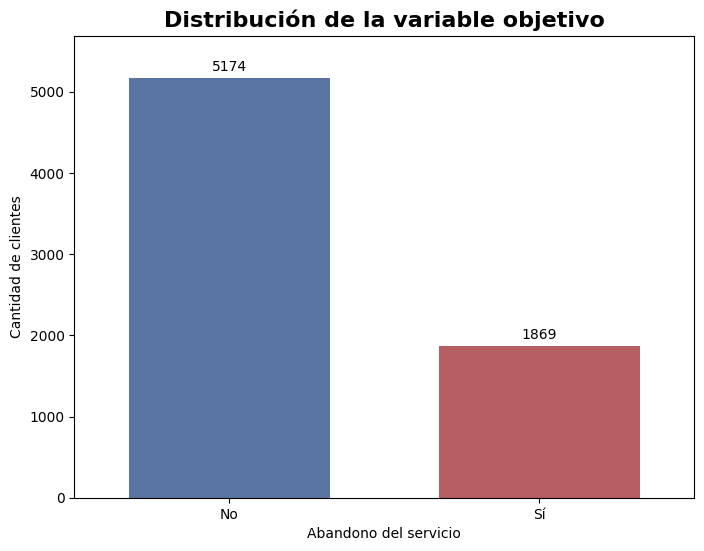

In [46]:
fig, ax = visualizaciones.graficar_distribucion_churn(
    df,
    ruta_salida="../resultados/plots/distribucion_variable_objetivo.png"
)
plt.show()

* La tasa general de churn es del 26.5%. Veamos entonces los distintos grupos de clientes. ¿Qué grupos presentan una mayor probabilidad de abandono?

#### Características Numéricas

Para las variables numéricas, se calculan y grafican las funciones de estimación de densidad de kernel (KDE).

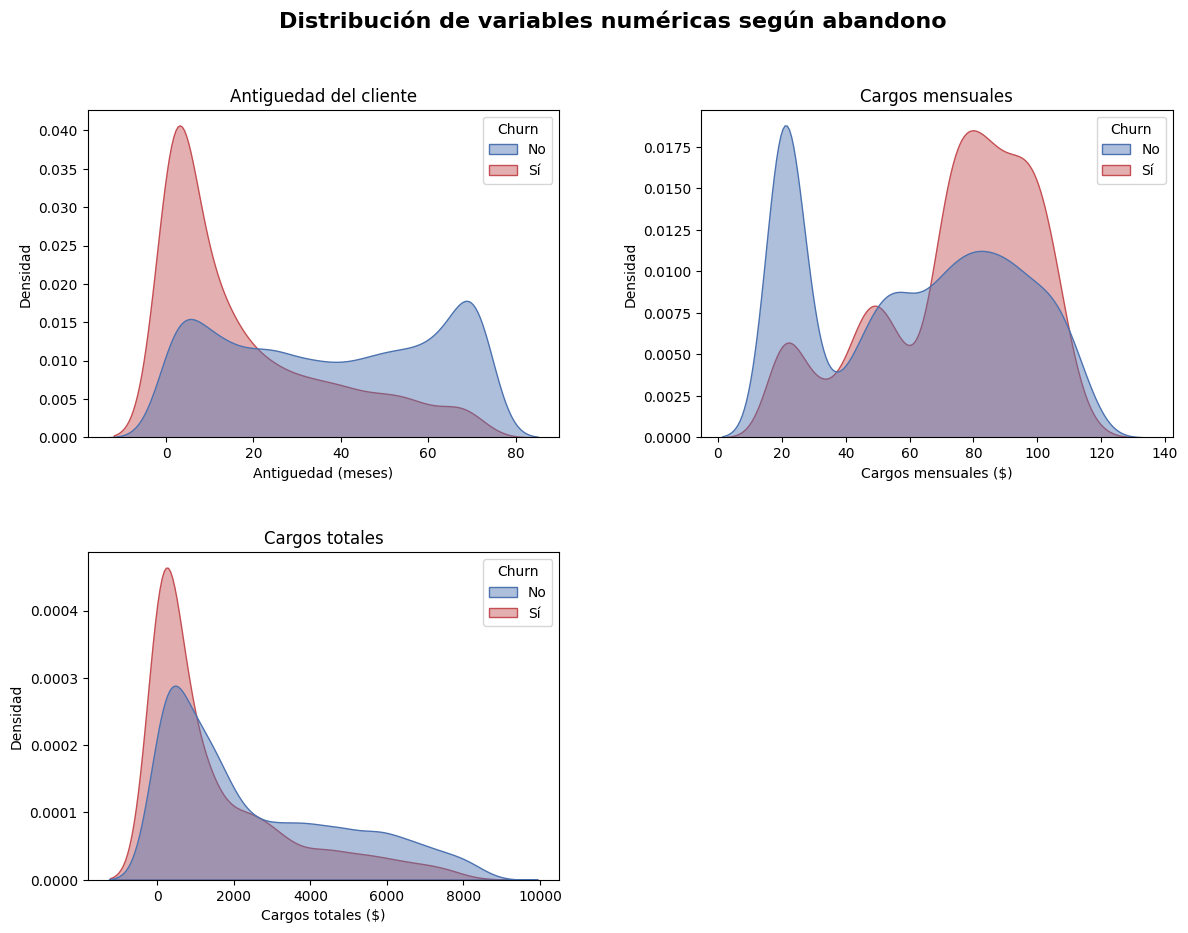

In [47]:
# generar curvas de densidad según la variable Churn
fig, axes = visualizaciones.graficar_curvas_densidad_churn(
    df,
    ruta_salida="../resultados/plots/curvas_densidad_churn.png"
)
plt.show()

In [48]:
# agrupar por 'Churn' y calcular el promedio
resumen = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)
tabla_churn_numeric = resumen.T
tabla_churn_numeric.columns = ['Churn = No', 'Churn = Sí']
tabla_churn_numeric

,Churn = No,Churn = Sí
tenure,37.57,17.98
MonthlyCharges,61.27,74.44
TotalCharges,2549.91,1531.80


Se pueden extraer las siguientes conclusiones:

**Antiguedad (Meses):**

* Los clientes activos tienen una antiguedad promedio de 37,57 meses.
* Quienes cancelaron el servicio muestran una permanencia menor, con un promedio de 17,98 meses.
* A mayor tiempo en la compañía, menor es la probabilidad de abandono.
* Los clientes nuevos con poca antiguedad tienen más probabilidades de cambiar de compañía.

**Cargos Mensuales:**

* El pago mensual promedio de los clientes activos es de $61,27.
* Quienes se dieron de baja pagaban una tarifa un poco mayor, cercana a los $74,44.
* Los clientes que pagan cargos mensuales más altos también tienen más probabilidades de cancelar el servicio.

**Cargos Totales:**

* Los clientes que mantienen su suscripción acumulan un promedio de $2554,77 en cargos totales.
* Quienes cancelaron el servicio acumularon un gasto inferior, de alrededor de $1531,80.
* Los usuarios con un mayor gasto total acumulado en el tiempo son más propensos a quedarse en la empresa.

### Variables Categóricas

Para las variables categóricas, los gráficos de barras muestran las diferencias entre los grupos objetivo.

#### Información de Clientes

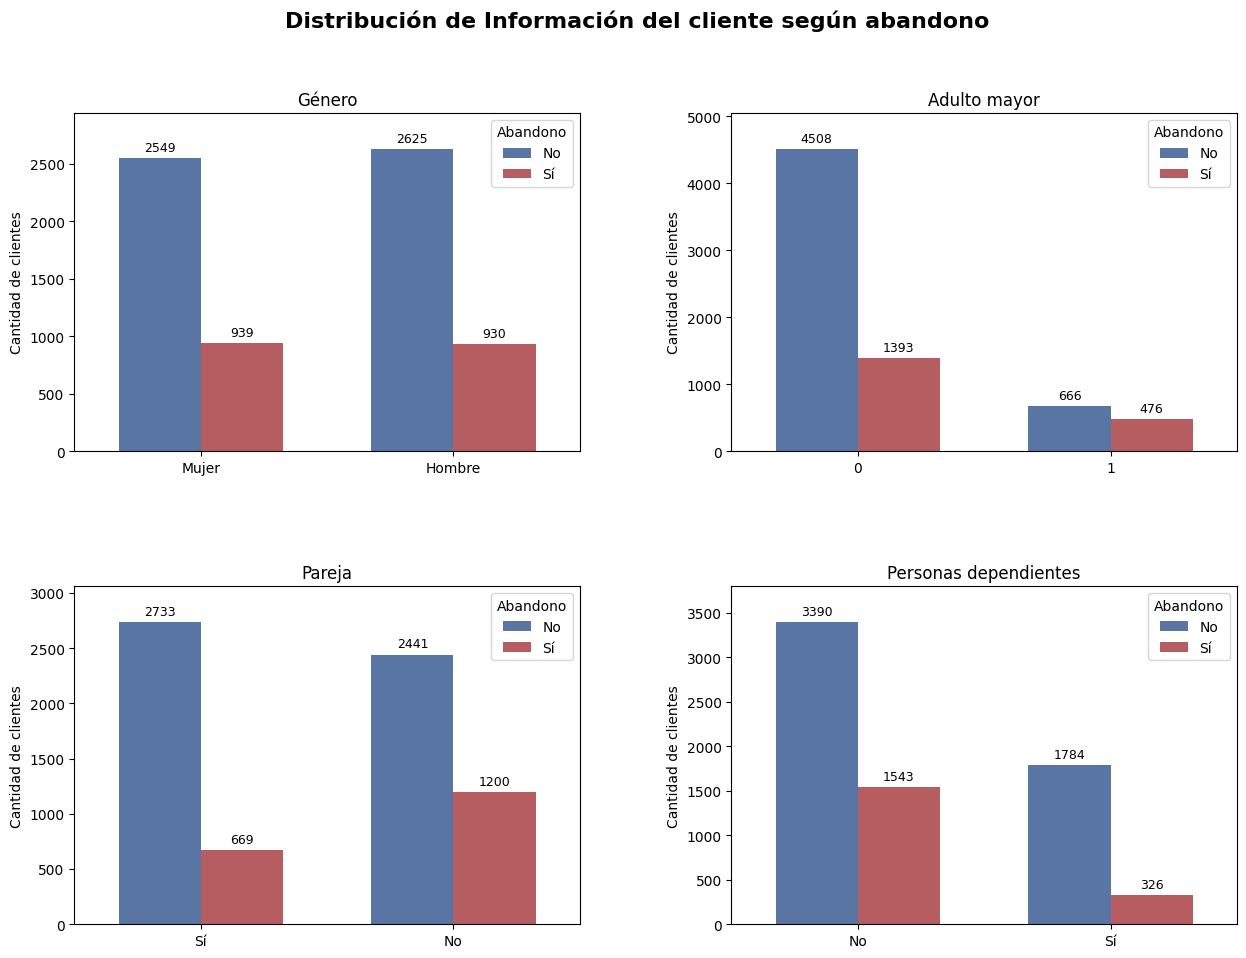

In [49]:
figura_cliente = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Información del cliente",
    ruta_salida="../resultados/plots"
)
display(figura_cliente)
plt.close(figura_cliente)

* La cantidad de cancelaciones es muy similar entre clientes hombres y mujeres, sin presentar una diferencia importante.
* Clientes sin pareja y clientes sin familiares (dependientes), así como los adultos mayores en proporción tiene mayor probabilidad de abono.
* Hay una baja proporción de adultos mayores, pero que al serlo es altamente probable que abandonen.

#### Servicios Contratados

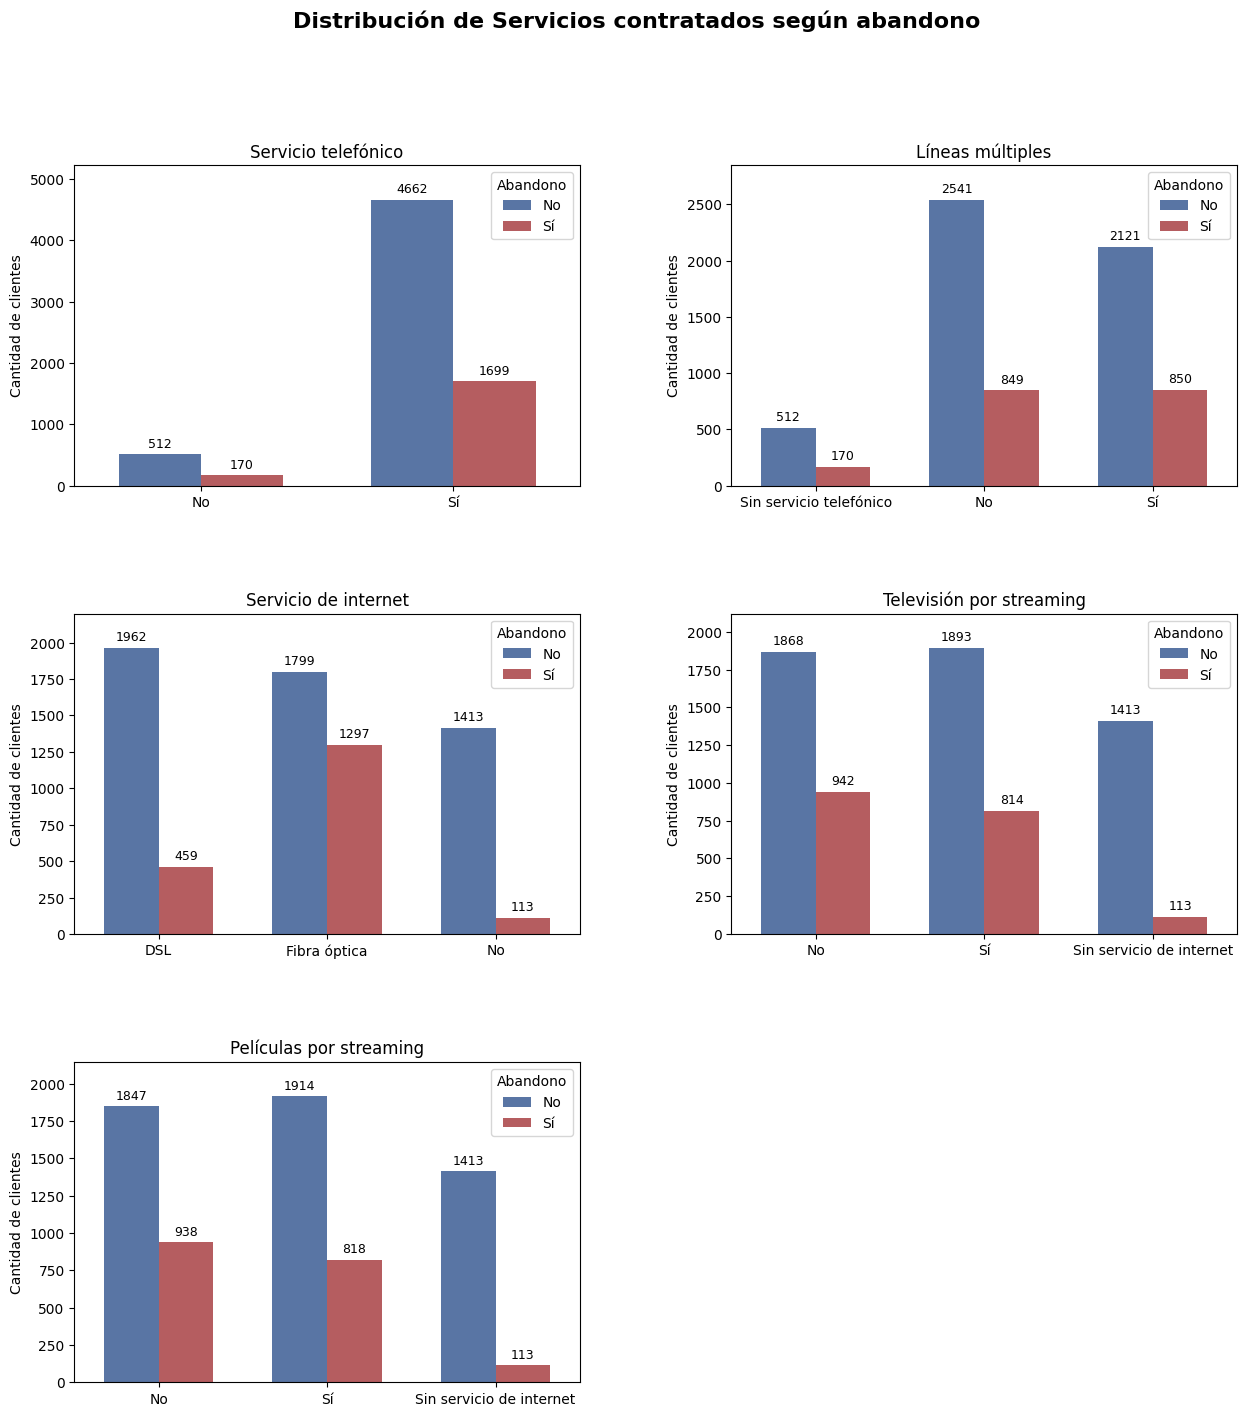

In [50]:
figura_servicios = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Servicios contratados",
    ruta_salida="../resultados/plots"
)
display(figura_servicios)
plt.close(figura_servicios)

* Un alto número de clientes con internet de fibra óptica cancelaron su servicio.
* Los usuarios con conexión DSL abandonan la compañía con menor frecuencia.
* Los clientes que no cuentan con servicio de internet presentan una tasa de abandono muy baja.
* Una gran parte de los clientes elige el servicio de fibra óptica, pero presentan una alta tasa de abandono, lo que sugiere una posible insatisfacción con este tipo de conexión.

#### Seguridad y soporte

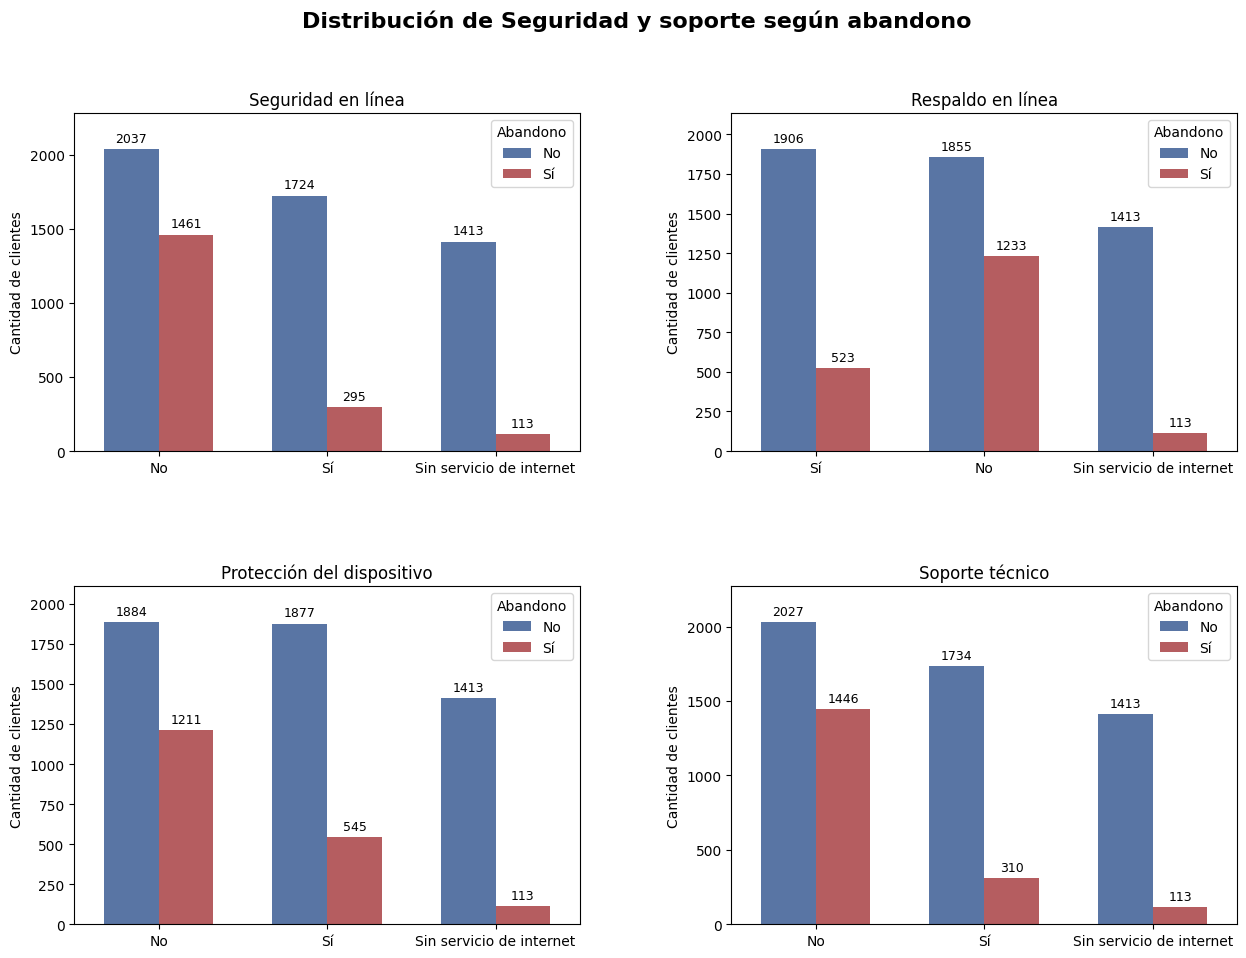

In [51]:
figura_seguridad = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Seguridad y soporte",
    ruta_salida="../resultados/plots"
)
display(figura_seguridad)
plt.close(figura_seguridad)

* Los clientes que contrataron servicios de seguridad o soporte técnico adicional tienen menos probabilidades de cancelar su servicio.

#### Información de Pago

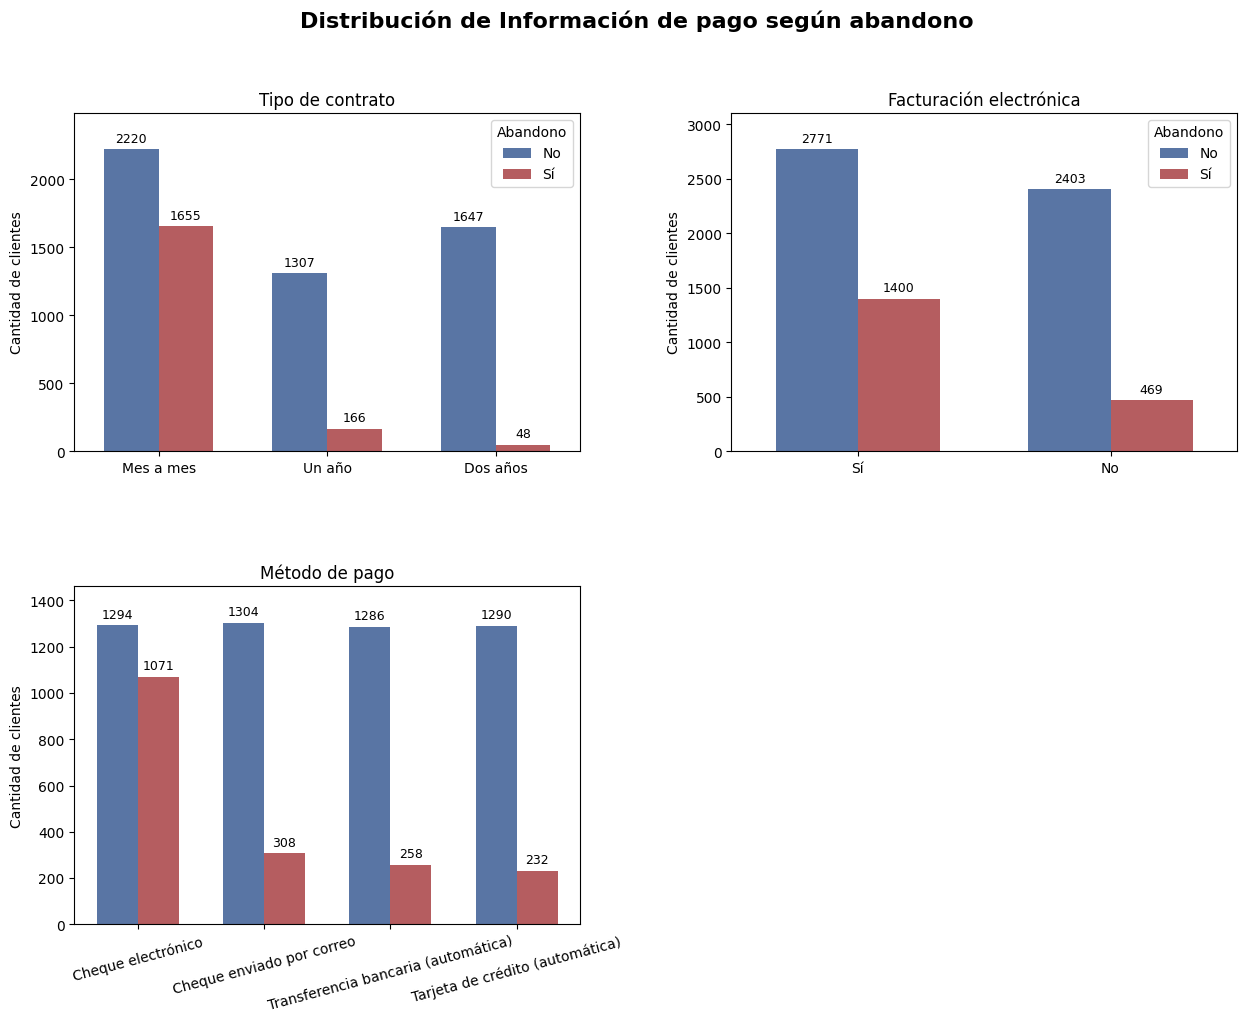

In [52]:
figura_pago = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Información de pago",
    ruta_salida="../resultados/plots"
)
display(figura_pago)
plt.close(figura_pago)

Grupos de clientes con alta probabilidad de cancelar su servicio:

* Clientes con contratos a corto plazo (mes a mes).
* Clientes con facturación electrónica (sin papel).
* Clientes que pagan con cheque electrónico.



# Limpieza y Transformación de Datos

In [53]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(object)

### Pipelines


In [54]:
pipeline_numeric = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5, weights="uniform")),
    ('scaler', StandardScaler())
])
pipeline_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
pipeline_preprocessor = ColumnTransformer([
    ("numeric", pipeline_numeric, df.select_dtypes(include=['int64', 'float64']).columns),
    ("categorical", pipeline_categorical, df.select_dtypes(include=['object']).columns.drop(['Churn', 'customerID']))
])

In [55]:
X_crudo = df.drop(['Churn', 'customerID'], axis=1) 
matriz_limpia = pipeline_preprocessor.fit_transform(X_crudo)

if hasattr(matriz_limpia, "toarray"):
    matriz_limpia = matriz_limpia.toarray()

df_limpia = pd.DataFrame(
    matriz_limpia,
    columns=pipeline_preprocessor.get_feature_names_out()
)
df_limpia['Churn'] = df['Churn'].values
df_limpia.head()

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__gender_Female,categorical__gender_Male,categorical__SeniorCitizen_0,categorical__SeniorCitizen_1,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,...,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,Churn
0,-1.277445,-1.160323,-0.992611,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
1,0.066327,-0.259629,-0.172165,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,-1.236724,-0.362660,-0.958066,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,0.514251,-0.746535,-0.193672,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0
4,-1.236724,0.197365,-0.938874,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1


In [56]:
df_limpia.to_csv('../data/Telco_Customer_Churn_limpio.csv', index = False, encoding = "utf-8")